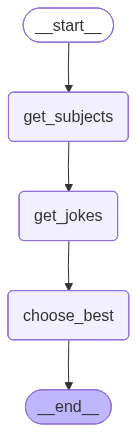

{'topic': 'Cats and Dogs', 'subjects': ["Mealtime Mishaps: The never-ending quest for the other's food bowl.", 'Communication Chaos: Decoding barks, meows, and the silent judgment of a cat.', 'Playtime Peculiarities: From enthusiastic fetch to the mysterious allure of a laser dot.', 'Household Hijinks: Sharing the sofa, claiming sunbeams, and dealing with the vacuum cleaner.', 'The Human Factor: Owners caught in the crossfire of canine enthusiasm and feline indifference.'], 'jokes': ['My cat and dog have a strict mealtime policy: their own food is lava, but the other\'s bowl is a gourmet buffet. They\'re convinced the secret ingredient is "not mine."', "My dog communicates with barks that are basically a full-blown press conference, while my cat just gives one meow, then stares, silently updating her 'Reasons I'm Disappointed in You' list.", "Alright, alright, settle down folks! You know, when it comes to playtime, dogs and cats are just... different. My dog plays fetch with the enthus

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from IPython.display import display, Image
load_dotenv()


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# ------------------------------
# STATES
# ------------------------------
class MainState(BaseModel):
    topic: str
    subjects: list[str] = []
    jokes: list[str] = []
    best_joke: str = ""

class SubjectsState(BaseModel):
    subjects: list[str]

# ------------------------------
# PROMPTS
# ------------------------------
subjects_prompt = PromptTemplate(
    template="""You are a helpful assistant to get 4-5 creative subtopics for the main theme: {topic}.
    These subtopics should be interesting and suitable for writing funny jokes about the main topic later.
    Return them in structured format (as a list of short strings)."""
)

joke_prompt = PromptTemplate(
    template="""You are a stand-up comedian. 
    Create a short, witty joke related to the following:
    - Main topic: {topic}
    - Specific subject: {subject}
    
    The joke should be light-hearted, one or two sentences, and easy to understand."""
)

# ------------------------------
# NODES
# ------------------------------

def get_subjects(state: MainState):
    structured_llm = llm.with_structured_output(SubjectsState)
    result = structured_llm.invoke([
        HumanMessage(content=subjects_prompt.format(topic=state.topic))
    ])
    return {"subjects": result.subjects}


def get_jokes(state: MainState):
    jokes = []
    for subject in state.subjects:
        prompt = joke_prompt.format(topic=state.topic, subject=subject)
        response = llm.invoke([HumanMessage(content=prompt)])
        jokes.append(response.content.strip())
    return {"jokes": jokes}


def choose_best(state: MainState):
    prompt = f"""You are judging the following jokes about {state.topic}.
    Pick the funniest one and return only that joke.
    Jokes:\n\n{chr(10).join(state.jokes)}"""
    result = llm.invoke([HumanMessage(content=prompt)])
    return {"best_joke": result.content.strip()}


# ------------------------------
# GRAPH BUILD
# ------------------------------
builder = StateGraph(MainState)

builder.add_node("get_subjects", get_subjects)
builder.add_node("get_jokes", get_jokes)
builder.add_node("choose_best", choose_best)

builder.add_edge(START, "get_subjects")
builder.add_edge("get_subjects", "get_jokes")
builder.add_edge("get_jokes", "choose_best")
builder.add_edge("choose_best", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

# ------------------------------
# RUN
# ------------------------------
result = graph.invoke({"topic": "Cats and Dogs"})
print(result)
